In [1]:
import pandas as pd
import json
import re
import numpy as np
import geopandas
import matplotlib.pyplot as plt
from dash import Dash, html, dcc, callback, Output, Input, dash_table
import dash_bootstrap_components as dbc
import plotly.express as px

ModuleNotFoundError: No module named 'dash'

In [ ]:
zdrowie= pd.read_csv('zdrowie.csv')
df=zdrowie
display(zdrowie.head())

,Nazwa,Rok,Szpitale,Pielegniarki_Polozne,Lekarze,Apteki,Punkty_apteczne,Osoby_swiadczenia_spoleczne,Placowki_ambulatoryjne,Ludnosc,...,placowki_ambulatoryjne_na_10tys,mieszkancow_na_apteke,lekarze_na_10tys_norm,pielegniarki_polozne_na_10tys_norm,apteki_i_punkty_na_10tys_norm,szpitale_na_10tys_norm,lozka_na_10tys_norm,placowki_ambulatoryjne_na_10tys_norm,indeks_dostepnosci,miejsce_w_rankingu
0,Łódzkie,2009,56.0,14030.0,12438.0,890.0,78.0,188740.0,1275.0,2541832.0,...,5.02,2855.99,0.433394,0.216012,0.71875,0.35,0.845302,0.419355,0.497,1
1,Lubelskie,2009,38.0,12818.0,10159.0,787.0,55.0,158038.0,949.0,2157202.0,...,4.40,2741.04,0.400000,0.295695,0.77500,0.15,0.828888,0.276498,0.454,2
2,Podlaskie,2009,30.0,7032.0,5087.0,322.0,64.0,103616.0,605.0,1189731.0,...,5.09,3694.82,0.321416,0.289841,0.36250,0.50,0.794419,0.435484,0.451,3
3,Śląskie,2009,107.0,29285.0,21084.0,1176.0,99.0,268378.0,2419.0,4640725.0,...,5.21,3946.19,0.369873,0.365181,0.05625,0.40,1.000000,0.463134,0.442,4
4,Dolnośląskie,2009,60.0,15879.0,11846.0,922.0,59.0,192644.0,1181.0,2876627.0,...,4.11,3119.99,0.292740,0.216012,0.46875,0.30,0.629462,0.209677,0.353,5


In [ ]:
wskazniki = [
    col for col in df.columns
    if col not in ["Nazwa", "Rok"]
]

In [ ]:
#!pip install dash
#!pip install dash_bootstrap_components
#!pip install dash-bootstrap-templates
#!pip install folium

In [ ]:
lata = sorted(df["Rok"].unique())
wojewodztwa = sorted(df["Nazwa"].unique())
kolumna_rankingu = df.columns[-1]

In [ ]:
# Lista wskaźników do wybrania
wskazniki = {
    "indeks_dostepnosci": "Indeks dostępności opieki zdrowotnej",
    "lekarze_na_10tys": "Lekarze na 10 tys. mieszkańców",
    "pielegniarki_polozne_na_10tys": "Pielęgniarki i położne na 10 tys. mieszkańców",
    "apteki_i_punkty_na_10tys": "Apteki i punkty apteczne na 10 tys. mieszkańców",
    "szpitale_na_10tys": "Szpitale na 10 tys. mieszkańców",
    "lozka_na_10tys": "Łóżka szpitalne na 10 tys. mieszkańców",
    "placowki_ambulatoryjne_na_10tys": "Placówki ambulatoryjne na 10 tys. mieszkańców"
}

# Domyślny wskaźnik
domyslny_wskaznik = "lekarze_na_10tys"


# Wykres średniego rankingu województw - niezależny od innych zmiennych
fig_srednie = px.bar(
    srednie.sort_values("miejsce_w_rankingu"),
    x="Nazwa",
    y="miejsce_w_rankingu",
    title="<b>Średnie miejsce województw w rankingu dostępności do opieki zdrowotnej</b>",
    labels={
        "Nazwa": "Województwo",
        "miejsce_w_rankingu": "Średnie miejsce w rankingu"
    }
)

app = Dash(external_stylesheets=[dbc.themes.BOOTSTRAP])
app.layout = dbc.Container([
    # Tytuł
    dbc.Row([
        dbc.Col([
            html.H1(
                "Dashboard: Dostęp do opieki zdrowotnej w Polsce",
                style={"textAlign": "center", "marginTop": "20px"}
            ),
            html.P(
                "Aplikacja pokazuje różnice między województwami w dostępie do opieki zdrowotnej "
                "na podstawie danych z GUS-u.",
                style={"textAlign": "center"}
            )
        ])
    ]),

    html.Hr(),
    # Sekcja filtrów
    dbc.Row([
        # Wybór roku
        dbc.Col([
            html.Label("Wybierz rok:"),
            dcc.Slider(
                min=min(lata),
                max=max(lata),
                step=None,
                value=max(lata), #domyslnie najnowszy rok, u nas 2024
                marks={str(rok): str(rok) for rok in lata}, #tworzy podpisy pod suwakiem dla każdego roku np. 2009 - 2009
                id="rok-slider"
            )
        ], width=12)

    ], style={"marginBottom": "30px"}), #30 pikseli przerwy marginesu dolnego dla następnego elementu

    # Wybór wskaźnika
    dbc.Row([
        dbc.Col([
            html.Label("Wybierz wskaźnik:"),
            dcc.Dropdown(
                options=[ #lista to rozwinięcia
                    {"label": nazwa, "value": kolumna}
                    for kolumna, nazwa in wskazniki.items()
                ],
                value=domyslny_wskaznik,
                id="wskaznik-dropdown"
            )
        ], width=6),

        # Wybór województwa do wykresu liniowego
        dbc.Col([
            html.Label("Wybierz województwo: "),
            dcc.Dropdown(
                df["Nazwa"].unique(),
                value=df["Nazwa"][0],
                id="wojewodztwo-dropdown"
            )
        ], width=6)

    ], style={"marginBottom": "20px"}),

    # Wybór kilku województw do porównania
    dbc.Row([
        dbc.Col([
            html.Label("Wybierz województwa do porównania: "),
            dcc.Dropdown(
                df["Nazwa"].unique(),
                value=df["Nazwa"][:4],
                multi=True,
                id="porownanie-dropdown"
            )
        ], width=12)
    ], style={"marginBottom": "30px"}),

    # Kafelki z informacjami
    dbc.Row([
        dbc.Col([
            dbc.Card([
                dbc.CardBody([
                    html.H5("Najlepsze województwo"),
                    html.H4(id="najlepsze-card")
                ])
            ])
        ], width=3),

        dbc.Col([
            dbc.Card([
                dbc.CardBody([
                    html.H5("Najsłabsze województwo"),
                    html.H4(id="najslabsze-card")
                ])
            ])
        ], width=3),

        dbc.Col([
            dbc.Card([
                dbc.CardBody([
                    html.H5("Średnia wartość"),
                    html.H4(id="srednia-card")
                ])
            ])
        ], width=3),
    ], style={"marginBottom": "30px"}),

    # Pierwszy rząd wykresów
    dbc.Row([
        dbc.Col([
            dcc.Graph(id="ranking-wykres")
        ], width=6),

        dbc.Col([
            dcc.Graph(id="czas-wykres")
        ], width=6)

    ]),

    # Drugi rząd wykresów
    dbc.Row([
        dbc.Col([
            dcc.Graph(id="porownanie-wykres")
        ], width=6),

        dbc.Col([
            dcc.Graph(id="scatter-wykres")
        ], width=6)
    ]),

    # Wykres średniego rankingu
    dbc.Row([
        dbc.Col([
            dcc.Graph(figure=fig_srednie)
        ], width=12)
    ]),

    # Tabela danych
    dbc.Row([
        dbc.Col([
            html.H4("Tabela danych dla wybranego roku"),
            dash_table.DataTable(
                id="tabela-danych",
                page_size=10,
                sort_action="native",
                filter_action="native",
                style_table={"overflowX": "auto"},
                style_cell={
                    "textAlign": "left",
                    "padding": "6px",
                    "fontFamily": "Arial"
                },
                style_header={
                    "fontWeight": "bold"
                }
            )
        ], width=12)
    ], style={"marginBottom": "40px"})

], fluid=True)


# Callback aktualizuje zmianę roku, wskaźnika i wybranego województwa
@app.callback(
    [
        Output("najlepsze-card", "children"), #children - dzieci elementu
        Output("najslabsze-card", "children"),
        Output("srednia-card", "children"),
        Output("ranking-wykres", "figure"),
        Output("czas-wykres", "figure"),
        Output("porownanie-wykres", "figure"),
        Output("scatter-wykres", "figure"),
        Output("tabela-danych", "data"),
        Output("tabela-danych", "columns")
    ],
    [
        Input("rok-slider", "value"),
        Input("wskaznik-dropdown", "value"),
        Input("wojewodztwo-dropdown", "value"),
        Input("porownanie-dropdown", "value")
    ]
)


def update_graph(rok, wskaznik, wojewodztwo, wojewodztwa):
    df_rok = df[df["Rok"] == rok].copy()

    # Sortowanie województw od najlepszego do najsłabszego wg. wybranego wskaźnika
    df_rok = df_rok.sort_values(wskaznik, ascending=False)

    # Wyciągamy podstawowe informacje do kafelków
    najlepsze_woj = df_rok.iloc[0]["Nazwa"]
    najslabsze_woj = df_rok.iloc[-1]["Nazwa"]
    srednia = df_rok[wskaznik].mean()

    # Ładne nazwy do wykresów wycigąnięte ze słownika wskaźniki
    nazwa_wskaznika = wskazniki[wskaznik]

    # Wykres 1 - ranking województw w wybranym roku
    fig_ranking = px.bar(
        df_rok,
        x="Nazwa",
        y=wskaznik, #zmienna
        title=f"Ranking województw dla {nazwa_wskaznika} w roku {rok}",
        labels={
            "Nazwa": "Województwo",
            wskaznik: nazwa_wskaznika
        }
    )

    # Wykres 2 - zmiana wybranego wskaźnika na przestrzeni lat dla województwa
    df_woj = df[df["Nazwa"] == wojewodztwo].copy()
    fig_czas = px.line(
        df_woj,
        x="Rok",
        y=wskaznik,
        markers=True,
        title=f"Zmiana w czasie: {wojewodztwo}",
        labels={
            "Rok": "Rok",
            wskaznik: nazwa_wskaznika
        }
    )

    # Wykres 3 - porównanie kilku województw
    df_porownanie = df[df["Nazwa"].isin(wojewodztwa)].copy() #tabela gdzie zostaja tylko te wiersze gdzie kolumna "Nazwa" znajduje się na liście województwa
    fig_porownanie = px.line(
        df_porownanie,
        x="Rok",
        y=wskaznik,
        color="Nazwa",
        markers=True,
        title="Porównanie województw w czasie",
        labels={
            "Rok": "Rok",
            wskaznik: nazwa_wskaznika,
            "Nazwa": "Województwo"
        }
    )

    # Wykres 4 - heatmapa znormalizowanych wskaźników zdrowotnych
    kolumny_heatmapy = [ "lekarze_na_10tys_norm", "pielegniarki_polozne_na_10tys_norm", "apteki_i_punkty_na_10tys_norm", "szpitale_na_10tys_norm","lozka_na_10tys_norm", "placowki_ambulatoryjne_na_10tys_norm"]

    #Poprawiamy nazwy na wykres
    nazwy_heatmapy = {"lekarze_na_10tys_norm": "Lekarze", "pielegniarki_polozne_na_10tys_norm": "Pielęgniarki i położne", "apteki_i_punkty_na_10tys_norm": "Apteki i punkty apteczne", "szpitale_na_10tys_norm": "Szpitale", "lozka_na_10tys_norm": "Łóżka szpitalne", "placowki_ambulatoryjne_na_10tys_norm": "Placówki ambulatoryjne"}

    # Przygotowujemy dane do heatmapy - Wiersze  to województwa kolumny to  wskaźniki
    df_heatmapa = (
        df_rok.sort_values("indeks_dostepnosci", ascending=False).set_index("Nazwa")[kolumny_heatmapy]
    )

    # Zmieniamy nazwy kolumn na czytelniejsze
    df_heatmapa = df_heatmapa.rename(columns=nazwy_heatmapy)

    #Heatmapa
    fig_scatter = px.imshow(
        df_heatmapa,
        text_auto=".2f",
        color_continuous_scale="RdYlGn",
        title=f"Porównanie wskaźników zdrowotnych w województwach na rok {rok}",
        labels={
            "x": "Wskaźnik",
            "y": "Województwo",
            "color": "Wartość znormalizowana"
        }
    )

    #Wygląd
    fig_scatter.update_layout(
        height=650,
        xaxis_tickangle=-30
    )

    # Dane do tabeli
    kolumny_tabeli = [
        "Nazwa",
        "Rok",
        wskaznik,
        "indeks_dostepnosci",
        "miejsce_w_rankingu"
    ]

    # Zostawiamy tylko te kolumny, które istnieją w danych
    kolumny_tabeli = [kol for kol in kolumny_tabeli if kol in df_rok.columns]
    tabela = df_rok[kolumny_tabeli].copy()

    # Format kolumn do DataTable
    columns = [
        {"name": kol, "id": kol}
        for kol in tabela.columns
    ]
    data = tabela.to_dict("records")

    return (
        najlepsze_woj,
        najslabsze_woj,
        round(srednia, 3),
        fig_ranking,
        fig_czas,
        fig_porownanie,
        fig_scatter,
        data,
        columns
    )

app.run(debug=True)


C:\Users\emili\AppData\Local\Temp\ipykernel_3508\3261657244.py:316: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  data = tabela.to_dict("records")


In [ ]:
srednie= pd.read_csv('srednie.csv')
display(srednie.head())

,Nazwa,miejsce_w_rankingu
0,Śląskie,2.00
1,Łódzkie,2.12
2,Lubelskie,2.75
3,Podlaskie,3.06
4,Dolnośląskie,5.88


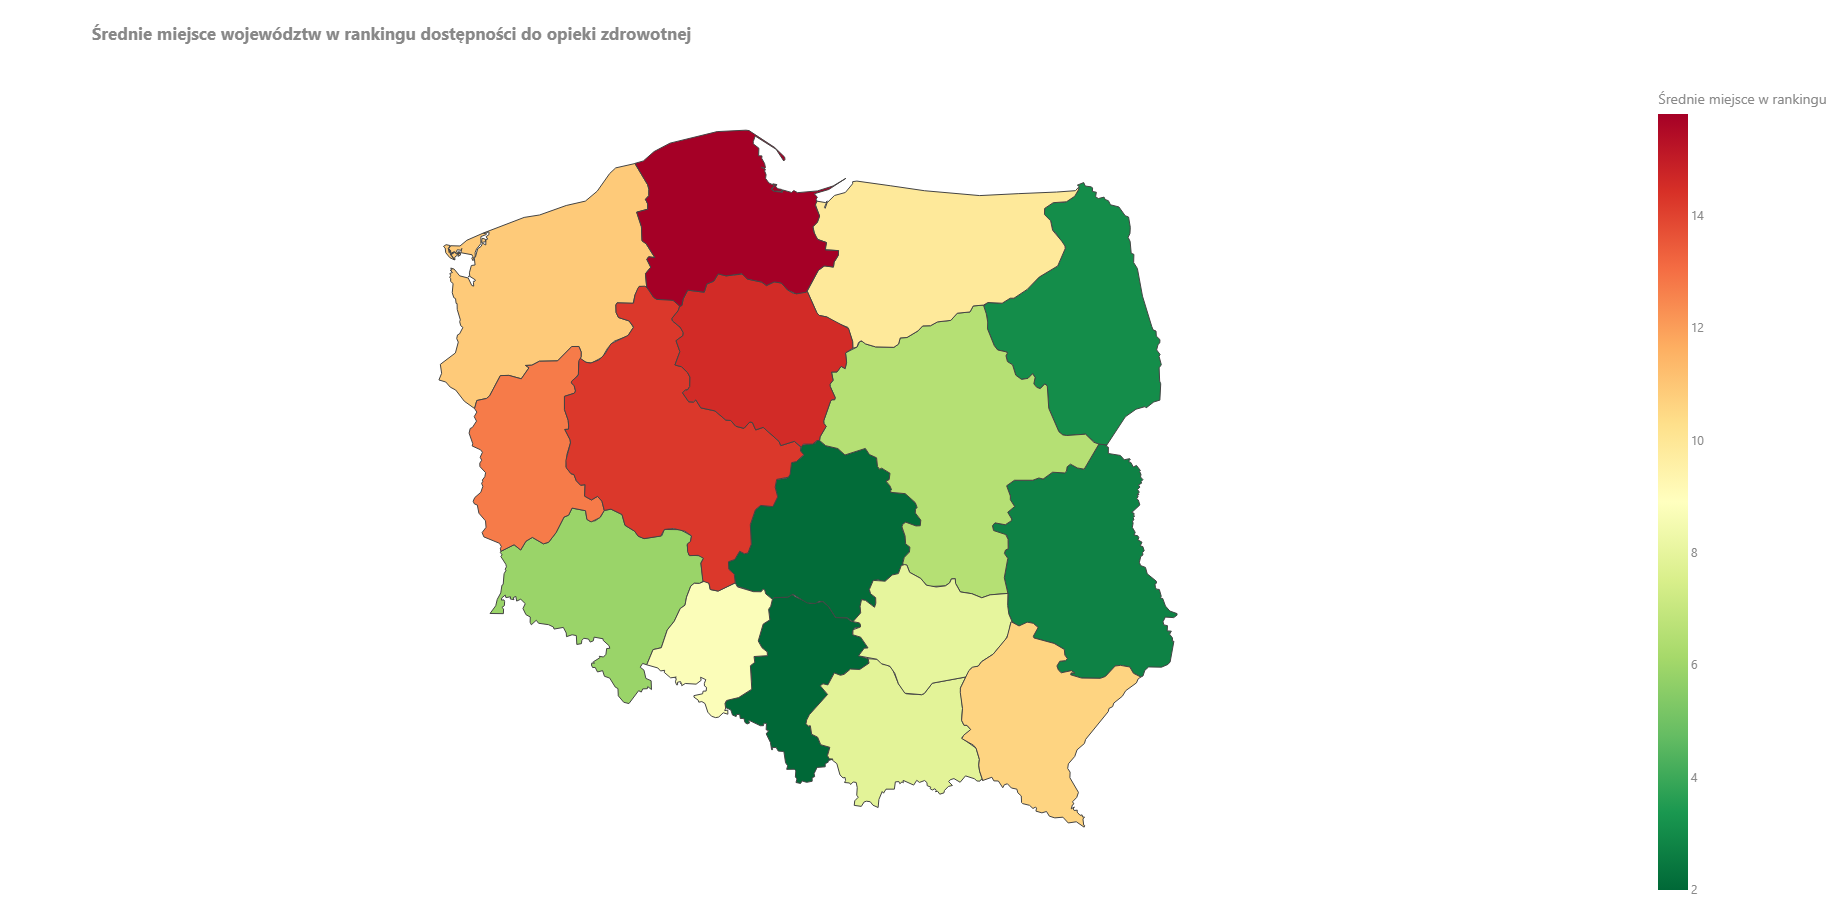

In [ ]:
#Wczytujemy plik GeoJSON z granicami województw
with open("polska-wojewodztwa.geojson", encoding="utf-8") as f:
    woj_geojson = json.load(f)

#W pliku GeoJSON nazwa województwa znajduje się w polu "name"
kolumna_nazwy_geo = "name"

#Tworzymy kopię tabeli, żeby nie zmieniać oryginalnego pliku srednie
srednie_mapa = srednie.copy()

#Dopasowujemy nazwy województw do nazw z pliku GeoJSON
mapa_nazw = {
    "Świętokrzyskie": "Swietokrzyskie",
    "Łódzkie": "Lódzkie",
    "Śląskie": "Slaskie",
    "Małopolskie": "Malopolskie",
    "Dolnośląskie": "Dolnoslaskie",
    "Warmińsko-Mazurskie": "Warminsko-Mazurskie"
}

#Nowa kolumna będzie służy połączeniu tabeli z mapą
srednie_mapa["Nazwa_geo"] = srednie_mapa["Nazwa"].replace(mapa_nazw)

#Mapa
fig_mapa_srednie = px.choropleth(
    srednie_mapa,
    geojson=woj_geojson,
    locations="Nazwa_geo",              #nazwa dopasowana do GeoJSON
    featureidkey="properties.name",     #nazwa województwa w pliku GeoJSON
    color="miejsce_w_rankingu",
    hover_name="Nazwa",                 #oryginalna nazwa
    hover_data={
        "Nazwa_geo": False,
        "miejsce_w_rankingu": ":.2f"
    },
    color_continuous_scale="RdYlGn_r",
    title="<b>Średnie miejsce województw w rankingu dostępności do opieki zdrowotnej</b>",
    labels={
        "miejsce_w_rankingu": "Średnie miejsce w rankingu"
    }
)
#Mapa do granic PL
fig_mapa_srednie.update_geos(
    fitbounds="locations",
    visible=False,
    projection_type="mercator"
)
#Wyglad
fig_mapa_srednie.update_layout(
    height=900,
    width=900,
    margin={"r": 0, "t": 80, "l": 0, "b": 0}
)

fig_mapa_srednie.show()